# ADF drift analysis (ROI template matching)

Notebook **independiente** de Fast4D. Carga las imágenes ADF guardadas por cada análisis y mide el **drift** (desplazamiento en píxeles) respecto a un **template**.

## Estructura esperada en disco

Tras un Compute/Save en Fast4D, cada scan queda en una subcarpeta con:

```
<carpeta_raíz_elegida>/
  <NombreScan1>/
    virtual_images/
      ADF.png
  <NombreScan2>/
    virtual_images/
      ADF.png
  ...
```

## Flujo

1. **Configurar** la carpeta raíz del batch.
2. **Elegir** qué archivo es el template (referencia).
3. **Dibujar un ROI** sobre la figura repetitiva que quieres seguir (un pilar, un cuadrante, etc.).
4. **Calcular drift** de cada ADF vs el template (correlación normalizada, ventana de búsqueda acotada para evitar saltos a pilares vecinos idénticos).
5. **Exportar** `tables/registration_shifts.csv` (formato repro4dstem) y comparación ADF antes/después del drift.

### Requisitos

```bash
pip install numpy matplotlib pandas pillow scikit-image ipywidgets ipympl
```

En Jupyter: `%matplotlib widget` para dibujar el ROI con el ratón. Sin `ipympl`, usa los sliders del notebook.

In [4]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Rectangle
from PIL import Image
from skimage.feature import match_template

try:
    import ipywidgets as widgets
except ImportError as exc:
    raise ImportError("Instala ipywidgets: pip install ipywidgets") from exc

HAS_IPYMPL = False
try:
    import ipympl  # noqa: F401
    HAS_IPYMPL = True
except ImportError:
    pass

# widget = ratón interactivo (ipympl); inline = vista estática / sliders.
get_ipython().run_line_magic("matplotlib", "widget" if HAS_IPYMPL else "inline")

ADF_REL = Path("virtual_images") / "ADF.png"

In [5]:
@dataclass
class AdfEntry:
    path: Path
    label: str
    scan_folder: str

    @property
    def rel_from_root(self) -> str:
        return str(self.path.parent.parent.name)


def discover_adf_images(root: str | Path) -> list[AdfEntry]:
    """Find every .../virtual_images/ADF.png under *root* (one per analysis folder)."""
    root = Path(root).expanduser().resolve()
    if not root.is_dir():
        raise FileNotFoundError(f"No es una carpeta: {root}")

    entries: list[AdfEntry] = []
    for png in sorted(root.rglob("ADF.png")):
        if png.parent.name.lower() != "virtual_images":
            continue
        scan_dir = png.parent.parent
        try:
            rel = scan_dir.relative_to(root)
            label = rel.as_posix()
        except ValueError:
            label = scan_dir.name
        entries.append(AdfEntry(path=png, label=label, scan_folder=scan_dir.name))

    # Deduplicate (same scan, multiple hits unlikely)
    seen: set[Path] = set()
    unique: list[AdfEntry] = []
    for e in entries:
        if e.path.resolve() in seen:
            continue
        seen.add(e.path.resolve())
        unique.append(e)
    return unique


def load_adf_gray(path: Path) -> np.ndarray:
    """Load ADF.png as float32 grayscale [0, 1]."""
    arr = np.asarray(Image.open(path).convert("L"), dtype=np.float32)
    if arr.ndim != 2:
        raise ValueError(f"Se esperaba imagen 2D: {path}")
    mx = float(arr.max()) or 1.0
    return arr / mx


def pick_quadrant_roi(shape: tuple[int, int], quadrant: str, *, margin_frac: float = 0.08) -> tuple[int, int, int, int]:
    """Quick ROI: one of TL / TR / BL / BR (half-image boxes with margin)."""
    h, w = shape
    mx = int(margin_frac * min(h, w))
    mid_y, mid_x = h // 2, w // 2
    q = quadrant.upper()
    if q == "TL":
        return mx, mid_y - mx, mx, mid_x - mx
    if q == "TR":
        return mx, mid_y - mx, mid_x + mx, w - mx
    if q == "BL":
        return mid_y + mx, h - mx, mx, mid_x - mx
    if q == "BR":
        return mid_y + mx, h - mx, mid_x + mx, w - mx
    raise ValueError(f"Cuadrante desconocido: {quadrant}")


def clamp_roi(y0: int, y1: int, x0: int, x1: int, h: int, w: int) -> tuple[int, int, int, int]:
    y0, y1 = max(0, min(y0, y1)), min(h, max(y0, y1))
    x0, x1 = max(0, min(x0, x1)), min(w, max(x0, x1))
    if y1 - y0 < 8 or x1 - x0 < 8:
        raise ValueError("ROI demasiado pequeño (mín. ~8 px por lado)")
    return y0, y1, x0, x1


def extract_patch(img: np.ndarray, roi: tuple[int, int, int, int]) -> np.ndarray:
    y0, y1, x0, x1 = roi
    return img[y0:y1, x0:x1].copy()


def match_drift(
    image: np.ndarray,
    template_patch: np.ndarray,
    template_anchor: tuple[int, int],
    *,
    search_margin: int = 80,
) -> dict:
    """Find where *template_patch* best matches in *image* near the anchor (ty, tx).

    Returns drift in pixels (dy, dx) = found - anchor. Positive dx → feature moved right.
    """
    ty, tx = template_anchor
    th, tw = template_patch.shape
    h, w = image.shape

    y0 = max(0, ty - search_margin)
    y1 = min(h, ty + th + search_margin)
    x0 = max(0, tx - search_margin)
    x1 = min(w, tx + tw + search_margin)
    search = image[y0:y1, x0:x1]

    corr = match_template(search, template_patch, pad_input=False)
    peak = np.unravel_index(int(np.argmax(corr)), corr.shape)
    found_y = y0 + peak[0]
    found_x = x0 + peak[1]

    dy = found_y - ty
    dx = found_x - tx
    peak_val = float(corr[peak])
    return {
        "dy_px": dy,
        "dx_px": dx,
        "peak_y": found_y,
        "peak_x": found_x,
        "correlation": peak_val,
        "search_box": (y0, y1, x0, x1),
    }


def apply_drift_shift(arr: np.ndarray, dy: float, dx: float) -> np.ndarray:
    """Desplaza *arr* por (dy, dx) px — convención repro4dstem (+dy mueve contenido abajo)."""
    from numpy.fft import fft2, ifft2, fftfreq

    a = np.asarray(arr, dtype=np.float64)
    h, w = a.shape[:2]
    mask_nan = ~np.isfinite(a)
    work = a.copy()
    work[mask_nan] = 0.0

    fy = fftfreq(h).reshape(-1, 1)
    fx = fftfreq(w).reshape(1, -1)
    phase = np.exp(-2j * np.pi * (dy * fy + dx * fx))
    shifted = np.real(ifft2(fft2(work) * phase))

    nan_shifted = np.real(ifft2(fft2(mask_nan.astype(np.float64)) * phase))
    shifted[nan_shifted > 0.5] = np.nan
    return shifted


def match_to_registration_shift(dy_px: float, dx_px: float) -> tuple[float, float]:
    """Convierte el drift del template-match a shift_dy/shift_dx del plugin."""
    return -float(dy_px), -float(dx_px)


def estimate_registration_error(ref_img: np.ndarray, mov_img: np.ndarray) -> float:
    """Error de registro (0..1, menor = mejor), como repro4dstem."""
    try:
        from skimage.registration import phase_cross_correlation
        _, error, _ = phase_cross_correlation(ref_img, mov_img, upsample_factor=10)
        return float(error)
    except Exception:
        return float("nan")


def to_registration_shifts_df(
    df: pd.DataFrame,
    *,
    template_img: np.ndarray | None = None,
    entries: list[AdfEntry] | None = None,
) -> pd.DataFrame:
    """DataFrame con columnas compatibles con ``tables/registration_shifts.csv``."""
    rows = []
    for _, r in df.iterrows():
        is_ref = bool(r["is_template"])
        if is_ref or not np.isfinite(r["dy_px"]):
            dy, dx, mag, err = 0.0, 0.0, 0.0, 0.0
        else:
            dy, dx = match_to_registration_shift(r["dy_px"], r["dx_px"])
            mag = float(np.hypot(dy, dx))
            err = float("nan")
            if template_img is not None and entries is not None:
                try:
                    mov = load_adf_gray(entries[int(r["idx"])].path)
                    if mov.shape == template_img.shape:
                        err = estimate_registration_error(template_img, mov)
                except Exception:
                    pass
            if not np.isfinite(err):
                err = float(max(0.0, 1.0 - r["correlation"]))

        rows.append({
            "scan_id": r["scan"],
            "shift_dy_px": dy,
            "shift_dx_px": dx,
            "shift_magnitude_px": mag,
            "error": err,
            "is_reference": is_ref,
            "notes": (r.get("note") or "") if isinstance(r.get("note"), str) else "",
        })
    return pd.DataFrame(rows)


def plot_adf_before_after(
    scan_id: str,
    before: np.ndarray,
    after: np.ndarray,
    *,
    shift_dy: float = 0.0,
    shift_dx: float = 0.0,
    ax_pair: tuple | None = None,
) -> tuple:
    """Panel antes/después para un scan. Devuelve (fig, axes) si crea la figura."""
    created = ax_pair is None
    if created:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    else:
        fig, axes = ax_pair[0], ax_pair[1]

    vmin = float(np.nanpercentile(before, 2))
    vmax = float(np.nanpercentile(before, 98))
    titles = (
        "Con drift (sin corregir)",
        f"Sin drift (corregido)  Δy={shift_dy:+.1f}, Δx={shift_dx:+.1f} px",
    )
    for ax, arr, title in zip(axes, (before, after), titles):
        ax.imshow(arr, cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_title(title, fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
    if created:
        fig.suptitle(scan_id, fontsize=10, y=1.02)
        fig.tight_layout()
    return fig, axes


def composite_adf_transparent(
    images: list[np.ndarray],
    *,
    alpha: float | None = None,
) -> np.ndarray:
    """Superpone todas las ADF en **una** imagen (ej. 512×512) con transparencia.

    Cada capa se mezcla con alpha; por defecto alpha = 1/N (todas con igual peso).
    Si hay drift entre scans, el fantasma/borroso del montaje lo hace visible.
    """
    if not images:
        raise ValueError("No hay imágenes para componer")
    imgs = [np.asarray(im, dtype=np.float64) for im in images]
    h, w = imgs[0].shape
    for im in imgs[1:]:
        if im.shape != (h, w):
            raise ValueError(f"Shape distinto: {im.shape} vs {(h, w)}")

    a = (1.0 / len(imgs)) if alpha is None else float(alpha)
    a = min(max(a, 0.01), 1.0)
    out = imgs[0].copy()
    for im in imgs[1:]:
        out = (1.0 - a) * out + a * im
    return np.clip(out, 0.0, 1.0)


def save_adf_composite_png(composite: np.ndarray, path: Path) -> Path:
    """Guarda el composite float [0,1] como PNG a resolución nativa (sin reescalar)."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    u8 = (np.clip(composite, 0, 1) * 255.0).astype(np.uint8)
    Image.fromarray(u8, mode="L").save(path)
    return path


def plot_adf_overlay_composites(
    before_images: list[np.ndarray],
    after_images: list[np.ndarray],
    *,
    ref_label: str = "",
    alpha: float | None = None,
) -> tuple[plt.Figure, np.ndarray, np.ndarray]:
    """Dos composites 512×512: izq = sin corrección, der = con corrección."""
    comp_before = composite_adf_transparent(before_images, alpha=alpha)
    comp_after = composite_adf_transparent(after_images, alpha=alpha)

    h, w = comp_before.shape
    vmin = float(np.nanpercentile(comp_before, 2))
    vmax = float(np.nanpercentile(comp_before, 98))

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    for ax, arr, title in zip(
        axes,
        (comp_before, comp_after),
        ("Sin drift correction (superposición)", "Con drift correction (superposición)"),
    ):
        ax.imshow(arr, cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_title(title, fontsize=9)
        ax.set_xlabel(f"{w} px")
        ax.set_ylabel(f"{h} px")
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(
        f"Montaje transparente ADF ({w}×{h}, n={len(before_images)}) — ref: {ref_label}",
        fontsize=10,
        y=1.02,
    )
    fig.tight_layout()
    return fig, comp_before, comp_after

## 1 — Elegir carpeta raíz y listar ADF

In [6]:
# ── CONFIG: edita ROOT_DIR y ejecuta esta celda ─────────────────────────────
ROOT_DIR = r"C:\Users\jtapiaca.ASURITE\Desktop\S3\05152026 - S3\Repetitividad\Analsisis Reproducibilidad new GUI"   # carpeta con subcarpetas <Scan>/virtual_images/ADF.png

root_text = widgets.Text(
    value=ROOT_DIR,
    description="Carpeta raíz:",
    style={"description_width": "110px"},
    layout=widgets.Layout(width="95%"),
)
scan_btn = widgets.Button(description="Buscar ADF.png", button_style="info")
out_list = widgets.Output()

# Variable global usada por las celdas siguientes (sobrevive mientras el kernel viva).
entries: list[AdfEntry] = []


def refresh_adf_list(path: str | None = None) -> list[AdfEntry]:
    """Descubre ADF bajo *path* (o root_text) y actualiza ``entries``."""
    global entries
    p = path if path is not None else root_text.value
    out_list.clear_output(wait=True)
    with out_list:
        try:
            entries = discover_adf_images(p)
        except Exception as exc:
            entries = []
            print(f"Error: {exc}")
            return entries
        if not entries:
            print("No se encontró ningún .../virtual_images/ADF.png bajo:")
            print(f"  {Path(p).expanduser().resolve()}")
            print("\nComprueba ROOT_DIR / el cuadro de texto y pulsa «Buscar ADF.png».")
            return entries
        print(f"Encontrados {len(entries)} ADF:\n")
        for i, e in enumerate(entries):
            print(f"  [{i:3d}] {e.label}  →  {e.path}")
        print("\n✓ Listo — ejecuta la celda «2 — Template + ROI».")
    return entries


scan_btn.on_click(lambda _: refresh_adf_list())
display(widgets.VBox([root_text, scan_btn, out_list]))

# No auto-buscar con la ruta placeholder; pulsa el botón o descomenta la línea siguiente:
# refresh_adf_list(ROOT_DIR)

## 2 — Template + ROI (cuadrante o caja manual)

**Antes:** ejecuta la celda 1 con tu carpeta y pulsa **Buscar ADF.png** (debe listar al menos un archivo).

Elige el **template** y define el ROI:
- **Cuadrante** TL/TR/BL/BR como punto de partida (al cambiar el desplegable),
- **Ratón** (recomendado): arrastra un rectángulo sobre la imagen (`pip install ipympl` + `%matplotlib widget`),
- **Sliders** + botón *Aplicar sliders* para ajuste fino.

Tras ajustar el ROI con el ratón, **no pulses «Resetear a cuadrante»** — pasa a la celda 3. Ese botón solo sirve si quieres volver al cuadrante y descartar el ROI manual.

El ROI debe cubrir **una sola** figura repetitiva (un pilar), no varias.

In [ ]:
# Si el kernel se reinició o entries está vacío, intenta redescubrir desde ROOT_DIR / root_text.
if not entries:
    try:
        refresh_adf_list(ROOT_DIR)
    except NameError:
        pass
if not entries:
    try:
        refresh_adf_list(root_text.value)
    except NameError:
        pass
if not entries:
    raise RuntimeError(
        "No hay ADF cargados. Ejecuta la celda 1, pon la carpeta correcta y pulsa «Buscar ADF.png»."
    )

# ── state shared across widgets ───────────────────────────────────────────────
STATE = {
    "template_idx": 0,
    "quadrant": "TL",
    "roi": None,           # (y0, y1, x0, x1)
    "roi_manual": False,   # True tras ratón o sliders; el cuadrante no lo pisa al redibujar
    "template_img": None,
    "search_margin": 80,
    "drag": None,          # mouse drag state
    "roi_fig": None,
}

template_dd = widgets.Dropdown(
    options=[(e.label, i) for i, e in enumerate(entries)],
    description="Template:",
    style={"description_width": "90px"},
    layout=widgets.Layout(width="95%"),
)
quad_dd = widgets.Dropdown(
    options=[("Top-Left (TL)", "TL"), ("Top-Right (TR)", "TR"),
             ("Bottom-Left (BL)", "BL"), ("Bottom-Right (BR)", "BR")],
    value="TL",
    description="Cuadrante:",
    style={"description_width": "90px"},
)
margin_slider = widgets.IntSlider(
    value=80, min=20, max=300, step=10,
    description="Margen búsq. (px):",
    style={"description_width": "130px"},
    readout_format="d",
)
roi_out = widgets.Output()
roi_info = widgets.HTML(value="")


def _load_template(idx: int) -> np.ndarray:
    img = load_adf_gray(entries[idx].path)
    STATE["template_img"] = img
    STATE["template_idx"] = int(idx)
    STATE["drag"] = None
    return img


def _roi_from_state(img: np.ndarray) -> tuple[int, int, int, int]:
    if STATE["roi"] is not None:
        return STATE["roi"]
    return pick_quadrant_roi(img.shape, STATE["quadrant"])


def _sync_sliders(roi: tuple[int, int, int, int]) -> None:
    try:
        sl_y0.value, sl_y1.value, sl_x0.value, sl_x1.value = roi
    except NameError:
        pass


def _set_roi(
    roi: tuple[int, int, int, int],
    *,
    sync_sliders: bool = True,
    manual: bool | None = None,
) -> None:
    STATE["roi"] = roi
    if manual is not None:
        STATE["roi_manual"] = manual
    y0, y1, x0, x1 = roi
    source = "manual (ratón/sliders)" if STATE["roi_manual"] else f"cuadrante {STATE['quadrant']}"
    roi_info.value = (
        f"<b>ROI:</b> y=[{y0}:{y1}], x=[{x0}:{x1}] "
        f"({y1 - y0}×{x1 - x0} px) · <i>{source}</i> · margen búsqueda: {STATE['search_margin']} px"
    )
    if sync_sliders:
        _sync_sliders(roi)


def _draw_template(*, enable_mouse: bool = True):
    """Redibuja template + ROI. Con enable_mouse=True: arrastra un rectángulo con el ratón."""
    roi_out.clear_output(wait=True)
    with roi_out:
        if enable_mouse and not HAS_IPYMPL:
            print("Instala ipympl para ROI con ratón:  python -m pip install ipympl")
            print("Reinicia el kernel tras instalar. Usando vista estática.")
            enable_mouse = False

        backend = "widget" if enable_mouse else "inline"
        get_ipython().run_line_magic("matplotlib", backend)

        if STATE["roi_fig"] is not None:
            plt.close(STATE["roi_fig"])
            STATE["roi_fig"] = None

        idx = int(template_dd.value)
        img = _load_template(idx)
        h, w = img.shape
        STATE["quadrant"] = quad_dd.value
        STATE["search_margin"] = int(margin_slider.value)
        roi = _roi_from_state(img)
        _set_roi(roi, sync_sliders=False)
        y0, y1, x0, x1 = roi

        fig, ax = plt.subplots(figsize=(7, 7))
        STATE["roi_fig"] = fig
        ax.imshow(img, cmap="gray", interpolation="nearest")
        title = f"Template: {entries[idx].label}"
        if enable_mouse:
            title += "\nArrastra con el ratón: esquina sup-izq → inf-der del ROI"
        ax.set_title(title)
        rect = Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="lime", linewidth=2)
        ax.add_patch(rect)
        ax.set_xlabel("x (px)")
        ax.set_ylabel("y (px)")

        if enable_mouse:
            drag = {"active": False, "x0": 0.0, "y0": 0.0}
            STATE["drag"] = drag

            def _update_rect(x_a: float, y_a: float, x_b: float, y_b: float) -> None:
                rx0, rx1 = sorted((x_a, x_b))
                ry0, ry1 = sorted((y_a, y_b))
                rect.set_xy((rx0, ry0))
                rect.set_width(rx1 - rx0)
                rect.set_height(ry1 - ry0)
                fig.canvas.draw_idle()

            def _on_press(event):
                if event.inaxes is not ax or event.button != 1:
                    return
                if event.xdata is None or event.ydata is None:
                    return
                drag["active"] = True
                drag["x0"], drag["y0"] = float(event.xdata), float(event.ydata)

            def _on_motion(event):
                if not drag["active"] or event.inaxes is not ax:
                    return
                if event.xdata is None or event.ydata is None:
                    return
                _update_rect(drag["x0"], drag["y0"], float(event.xdata), float(event.ydata))

            def _on_release(event):
                if not drag["active"]:
                    return
                drag["active"] = False
                if event.inaxes is not ax or event.xdata is None or event.ydata is None:
                    return
                try:
                    new_roi = clamp_roi(
                        int(min(drag["y0"], event.ydata)),
                        int(max(drag["y0"], event.ydata)),
                        int(min(drag["x0"], event.xdata)),
                        int(max(drag["x0"], event.xdata)),
                        h, w,
                    )
                except ValueError as exc:
                    print(exc)
                    return
                _set_roi(new_roi, manual=True)
                ry0, ry1, rx0, rx1 = new_roi
                _update_rect(rx0, ry0, rx1, ry1)
                print(f"ROI manual guardado: y=[{ry0}:{ry1}], x=[{rx0}:{rx1}]")
                print("No pulses «Resetear a cuadrante» si quieres conservar este ROI.")

            fig.canvas.mpl_connect("button_press_event", _on_press)
            fig.canvas.mpl_connect("motion_notify_event", _on_motion)
            fig.canvas.mpl_connect("button_release_event", _on_release)

        plt.show()
        _sync_sliders(STATE["roi"])


def _apply_quadrant(_=None, *, force: bool = False):
    """Solo sustituye el ROI por el cuadrante elegido (borra un ROI manual)."""
    if STATE["roi_manual"] and not force:
        print(
            "Ya tienes un ROI manual. «Resetear a cuadrante» lo reemplaza; "
            "si quieres conservarlo, sigue con la celda 3."
        )
        return
    img = STATE["template_img"] if STATE["template_img"] is not None else _load_template(template_dd.value)
    STATE["quadrant"] = quad_dd.value
    roi = pick_quadrant_roi(img.shape, STATE["quadrant"])
    _set_roi(roi, manual=False)
    _draw_template(enable_mouse=True)


def _force_quadrant(_=None):
    _apply_quadrant(force=True)


def _apply_sliders(_=None):
    img = STATE["template_img"] if STATE["template_img"] is not None else _load_template(template_dd.value)
    h, w = img.shape
    try:
        roi = clamp_roi(sl_y0.value, sl_y1.value, sl_x0.value, sl_x1.value, h, w)
    except ValueError as exc:
        print(exc)
        return
    _set_roi(roi, manual=True)
    _draw_template(enable_mouse=True)


def _on_template_change(change):
    if change["name"] != "value":
        return
    img = _load_template(change["new"])
    roi = pick_quadrant_roi(img.shape, quad_dd.value)
    sl_y0.max = sl_y1.max = img.shape[0]
    sl_x0.max = sl_x1.max = img.shape[1]
    _set_roi(roi, manual=False)


btn_mouse = widgets.Button(description="Dibujar ROI con ratón", button_style="warning")
btn_show = widgets.Button(description="Vista estática", button_style="success")
btn_quad = widgets.Button(description="Resetear a cuadrante", button_style="")
btn_sliders = widgets.Button(description="Aplicar sliders", button_style="info")
btn_mouse.on_click(lambda _: _draw_template(enable_mouse=True))
btn_show.on_click(lambda _: _draw_template(enable_mouse=False))
btn_quad.on_click(_force_quadrant)
btn_sliders.on_click(_apply_sliders)

def _on_quadrant_change(change):
    if change["name"] != "value":
        return
    _apply_quadrant()

quad_dd.observe(_on_quadrant_change, names="value")

img0 = _load_template(template_dd.value)
h0, w0 = img0.shape
STATE["roi"] = pick_quadrant_roi(img0.shape, "TL")
STATE["roi_manual"] = False

sl_y0 = widgets.IntSlider(min=0, max=max(h0 - 8, 8), value=STATE["roi"][0], description="y0")
sl_y1 = widgets.IntSlider(min=8, max=h0, value=STATE["roi"][1], description="y1")
sl_x0 = widgets.IntSlider(min=0, max=max(w0 - 8, 8), value=STATE["roi"][2], description="x0")
sl_x1 = widgets.IntSlider(min=8, max=w0, value=STATE["roi"][3], description="x1")

template_dd.observe(_on_template_change, names="value")

display(widgets.VBox([
    template_dd,
    widgets.HBox([quad_dd, margin_slider]),
    widgets.HBox([btn_mouse, btn_quad, btn_show, btn_sliders]),
    widgets.Label("Ajuste fino (sliders + «Aplicar sliders»):"),
    widgets.HBox([sl_y0, sl_y1, sl_x0, sl_x1]),
    roi_info,
    roi_out,
]))
_set_roi(STATE["roi"])
_draw_template(enable_mouse=True)

## 3 — Calcular drift vs template

## 4 — Comparación ADF antes/después y exportación (`tables/registration_shifts.csv`)

,idx,scan,path,is_template,dy_px,dx_px,drift_px,correlation,note
0,0,Scan03_512 - corrected angles,C:\Users\jtapiaca.ASURITE\Desktop\S3\05152026 - S3\Repetitividad\Analsisis Reproducibilidad new GUI\Scan03_512 - corrected angles\virtual_images\ADF.png,True,+0.00,+0.00,0.00,1.0000,template
1,1,Scan04_512 - corrected angles,C:\Users\jtapiaca.ASURITE\Desktop\S3\05152026 - S3\Repetitividad\Analsisis Reproducibilidad new GUI\Scan04_512 - corrected angles\virtual_images\ADF.png,False,-10.00,-2.00,10.20,0.9953,
2,2,Scan05_512 - corrected angles,C:\Users\jtapiaca.ASURITE\Desktop\S3\05152026 - S3\Repetitividad\Analsisis Reproducibilidad new GUI\Scan05_512 - corrected angles\virtual_images\ADF.png,False,-25.00,-5.00,25.50,0.9949,
3,3,Scan06_512 - corrected angles,C:\Users\jtapiaca.ASURITE\Desktop\S3\05152026 - S3\Repetitividad\Analsisis Reproducibilidad new GUI\Scan06_512 - corrected angles\virtual_images\ADF.png,False,-37.00,-7.00,37.66,0.9769,
4,4,Scan07_512 - corrected angles,C:\Users\jtapiaca.ASURITE\Desktop\S3\05152026 - S3\Repetitividad\Analsisis Reproducibilidad new GUI\Scan07_512 - corrected angles\virtual_images\ADF.png,False,-53.00,-9.00,53.76,0.9918,
5,5,Scan08_512 - corrected angles,C:\Users\jtapiaca.ASURITE\Desktop\S3\05152026 - S3\Repetitividad\Analsisis Reproducibilidad new GUI\Scan08_512 - corrected angles\virtual_images\ADF.png,False,-66.00,-12.00,67.08,0.9906,
6,6,Scan09_512 - corrected angles,C:\Users\jtapiaca.ASURITE\Desktop\S3\05152026 - S3\Repetitividad\Analsisis Reproducibilidad new GUI\Scan09_512 - corrected angles\virtual_images\ADF.png,False,+17.00,+1.00,17.03,0.9949,


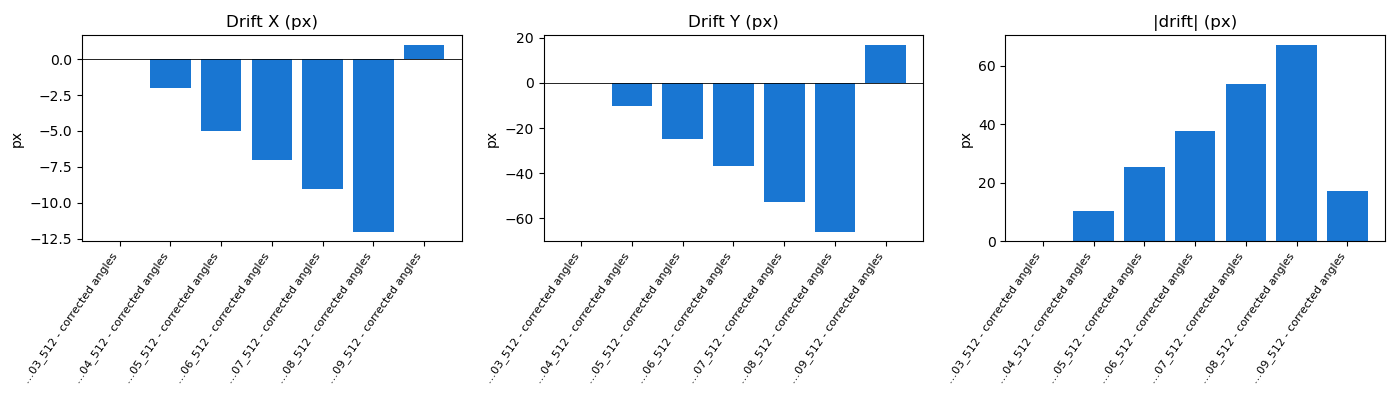

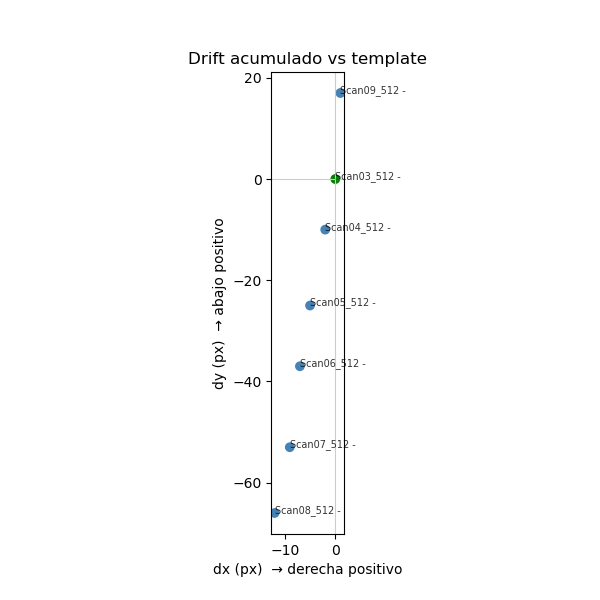

In [8]:
def run_drift_analysis(
    entries: list[AdfEntry],
    template_idx: int,
    roi: tuple[int, int, int, int],
    *,
    search_margin: int = 80,
) -> pd.DataFrame:
    template_img = load_adf_gray(entries[template_idx].path)
    y0, y1, x0, x1 = roi
    patch = extract_patch(template_img, roi)
    anchor = (y0, x0)   # top-left of patch in template

    rows = []
    for i, ent in enumerate(entries):
        img = load_adf_gray(ent.path)
        if img.shape != template_img.shape:
            rows.append({
                "idx": i,
                "scan": ent.label,
                "path": str(ent.path),
                "is_template": i == template_idx,
                "dy_px": np.nan,
                "dx_px": np.nan,
                "drift_px": np.nan,
                "correlation": np.nan,
                "note": f"shape mismatch {img.shape} vs {template_img.shape}",
            })
            continue

        if i == template_idx:
            m = {"dy_px": 0.0, "dx_px": 0.0, "correlation": 1.0, "note": "template"}
        else:
            m = match_drift(img, patch, anchor, search_margin=search_margin)
            m["note"] = ""

        drift = float(np.hypot(m["dy_px"], m["dx_px"]))
        rows.append({
            "idx": i,
            "scan": ent.label,
            "path": str(ent.path),
            "is_template": i == template_idx,
            "dy_px": m["dy_px"],
            "dx_px": m["dx_px"],
            "drift_px": drift,
            "correlation": m["correlation"],
            "note": m.get("note", ""),
        })
    return pd.DataFrame(rows)


# ── ejecutar ──────────────────────────────────────────────────────────────────
if not entries:
    raise RuntimeError("Sin ADF — ejecuta las celdas 1 y 2 primero.")
if STATE.get("roi") is None:
    raise RuntimeError("Define un ROI en la celda anterior (cuadrante, sliders o 2 clics).")

df = run_drift_analysis(
    entries,
    template_idx=STATE["template_idx"],
    roi=STATE["roi"],
    search_margin=int(STATE["search_margin"]),
)

display(df.style.format({
    "dy_px": "{:+.2f}",
    "dx_px": "{:+.2f}",
    "drift_px": "{:.2f}",
    "correlation": "{:.4f}",
}))

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x = np.arange(len(df))
labels = [s if len(s) < 28 else "…" + s[-25:] for s in df["scan"]]

for ax, col, title in zip(
    axes,
    ["dx_px", "dy_px", "drift_px"],
    ["Drift X (px)", "Drift Y (px)", "|drift| (px)"],
):
    ax.bar(x, df[col], color=np.where(df["is_template"], "#4CAF50", "#1976D2"))
    ax.axhline(0, color="k", lw=0.6)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=55, ha="right", fontsize=8)
    ax.set_ylabel("px")

plt.tight_layout()
plt.show()

# Scatter acumulado (trayectoria de drift)
fig2, ax2 = plt.subplots(figsize=(6, 6))
ok = df["dx_px"].notna()
ax2.axhline(0, color="#ccc", lw=0.8)
ax2.axvline(0, color="#ccc", lw=0.8)
ax2.scatter(df.loc[ok, "dx_px"], df.loc[ok, "dy_px"], c=np.where(df.loc[ok, "is_template"], "green", "steelblue"))
for _, r in df.loc[ok].iterrows():
    ax2.annotate(r["scan"].split("/")[-1][:12], (r["dx_px"], r["dy_px"]), fontsize=7, alpha=0.8)
ax2.set_xlabel("dx (px)  → derecha positivo")
ax2.set_ylabel("dy (px)  → abajo positivo")
ax2.set_title("Drift acumulado vs template")
ax2.set_aspect("equal", adjustable="box")
plt.show()

,scan_id,shift_dy_px,shift_dx_px,shift_magnitude_px,error,is_reference,notes
0,Scan03_512 - corrected angles,+0.00,+0.00,0.00,0.0000,True,template
1,Scan04_512 - corrected angles,+10.00,+2.00,10.20,1.0000,False,
2,Scan05_512 - corrected angles,+25.00,+5.00,25.50,1.0000,False,
3,Scan06_512 - corrected angles,+37.00,+7.00,37.66,1.0000,False,
4,Scan07_512 - corrected angles,+53.00,+9.00,53.76,1.0000,False,
5,Scan08_512 - corrected angles,+66.00,+12.00,67.08,1.0000,False,
6,Scan09_512 - corrected angles,-17.00,-1.00,17.03,1.0000,False,


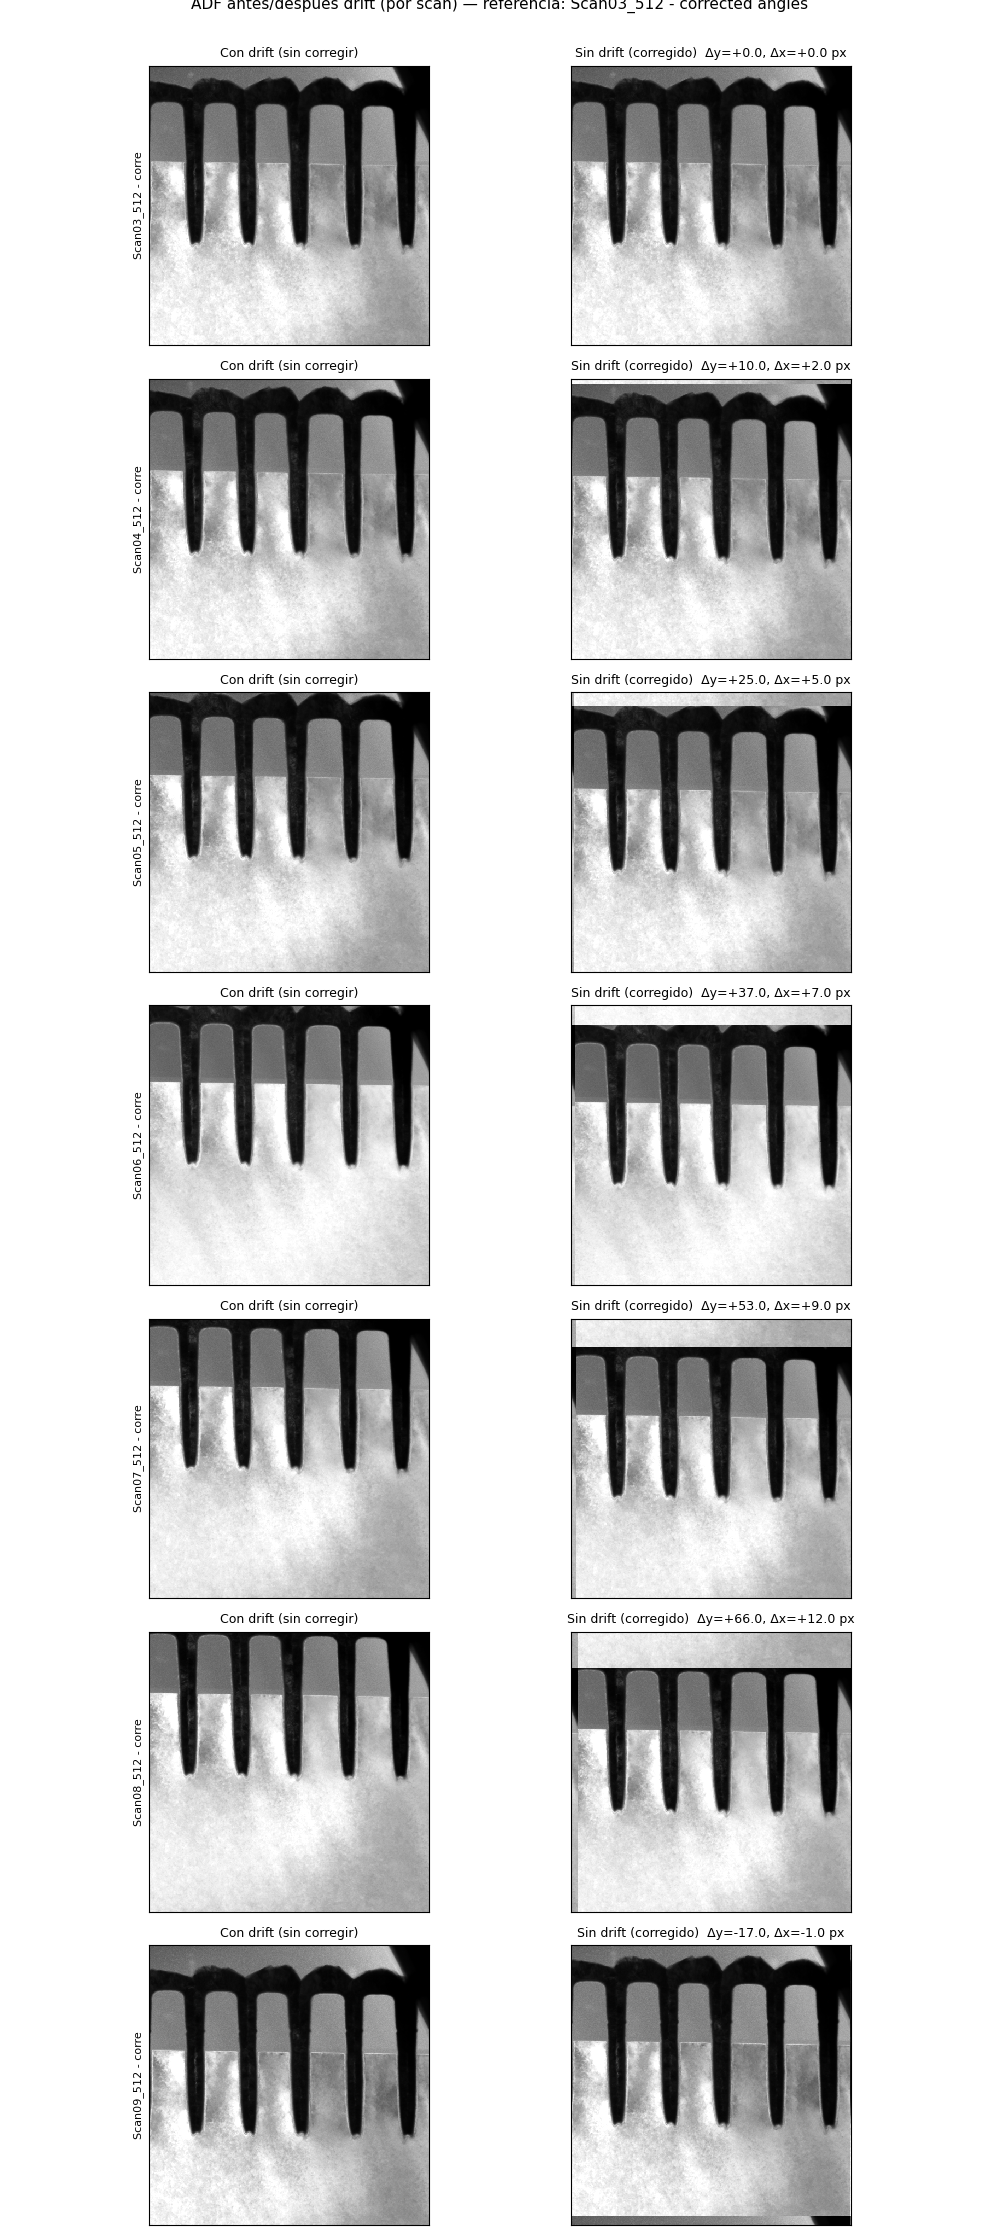

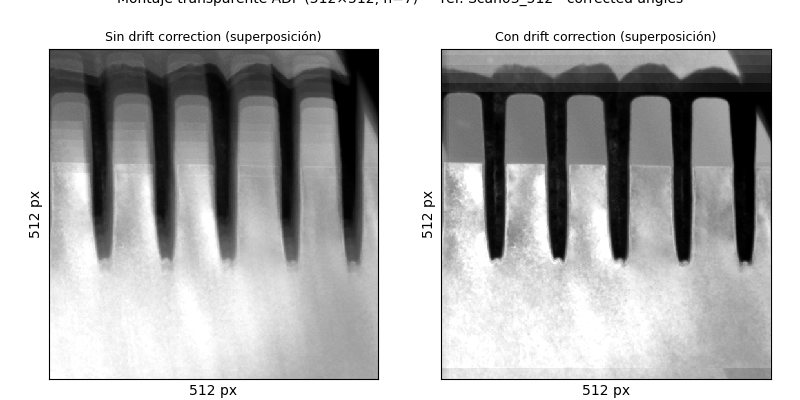

Guardado: C:\Users\jtapiaca.ASURITE\Desktop\S3\05152026 - S3\Repetitividad\Analsisis Reproducibilidad new GUI\tables\registration_shifts.csv
Guardado: C:\Users\jtapiaca.ASURITE\Desktop\S3\05152026 - S3\Repetitividad\Analsisis Reproducibilidad new GUI\plots\adf_montage_before_after_pairs.png
Guardado: C:\Users\jtapiaca.ASURITE\Desktop\S3\05152026 - S3\Repetitividad\Analsisis Reproducibilidad new GUI\plots\adf_overlay_sin_drift.png
Guardado: C:\Users\jtapiaca.ASURITE\Desktop\S3\05152026 - S3\Repetitividad\Analsisis Reproducibilidad new GUI\plots\adf_overlay_con_drift.png
Guardado: C:\Users\jtapiaca.ASURITE\Desktop\S3\05152026 - S3\Repetitividad\Analsisis Reproducibilidad new GUI\plots\adf_overlay_antes_despues.png
Guardados 7 paneles en: C:\Users\jtapiaca.ASURITE\Desktop\S3\05152026 - S3\Repetitividad\Analsisis Reproducibilidad new GUI\registration_checks


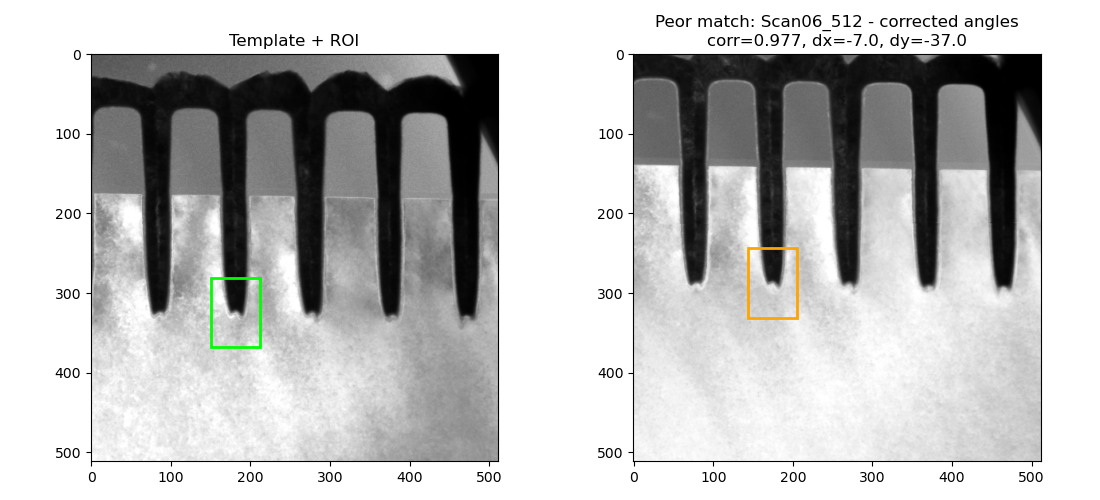

In [9]:
# ── 4a) Comparación ADF: antes (con drift) vs después (corregido) ─────────────
batch_root = Path(root_text.value).expanduser().resolve()
template_img = load_adf_gray(entries[STATE["template_idx"]].path)
ref_label = entries[STATE["template_idx"]].label

df_reg = to_registration_shifts_df(df, template_img=template_img, entries=entries)
display(df_reg.style.format({
    "shift_dy_px": "{:+.2f}",
    "shift_dx_px": "{:+.2f}",
    "shift_magnitude_px": "{:.2f}",
    "error": "{:.4f}",
}))

# Cargar pares antes/después una sola vez (reutilizado en todos los montajes)
adf_pairs: list[tuple[str, np.ndarray, np.ndarray]] = []
for _, r in df.iterrows():
    ent = entries[int(r["idx"])]
    before = load_adf_gray(ent.path)
    reg_row = df_reg.loc[df_reg["scan_id"] == r["scan"]].iloc[0]
    shift_dy = float(reg_row["shift_dy_px"])
    shift_dx = float(reg_row["shift_dx_px"])
    after = apply_drift_shift(before, shift_dy, shift_dx) if not bool(r["is_template"]) else before.copy()
    adf_pairs.append((r["scan"], before, after))

n_scans = len(adf_pairs)
fig_grid, axes_grid = plt.subplots(n_scans, 2, figsize=(10, 3.2 * n_scans), squeeze=False)
if n_scans == 1:
    axes_grid = np.array([axes_grid[0]])

for row, (label, before, after) in enumerate(adf_pairs):
    reg_row = df_reg.loc[df_reg["scan_id"] == label].iloc[0]
    plot_adf_before_after(
        label,
        before,
        after,
        shift_dy=float(reg_row["shift_dy_px"]),
        shift_dx=float(reg_row["shift_dx_px"]),
        ax_pair=(fig_grid, axes_grid[row]),
    )
    axes_grid[row, 0].set_ylabel(label.split("/")[-1][:18], fontsize=8)

fig_grid.suptitle(
    f"ADF antes/después drift (por scan) — referencia: {ref_label}",
    fontsize=11,
    y=1.002,
)
plt.tight_layout()
plt.show()

# Montaje transparente: una sola imagen 512×512 con TODAS las ADF superpuestas
before_stack = [before for _, before, _ in adf_pairs]
after_stack = [after for _, _, after in adf_pairs]
fig_overlay, comp_before, comp_after = plot_adf_overlay_composites(
    before_stack,
    after_stack,
    ref_label=ref_label,
)
plt.show()

# ── 4b) Exportar en estructura tipo repro4dstem ─────────────────────────────
# Por defecto bajo la carpeta raíz del batch:
#   tables/registration_shifts.csv
#   registration_checks/adf_before_after_<scan>.png
#   plots/adf_montage_before_after_pairs.png
#   plots/adf_overlay_sin_drift.png          (una imagen 512×512, todas superpuestas)
#   plots/adf_overlay_con_drift.png
#   plots/adf_overlay_antes_despues.png
# Para escribir en el Drift del experimento (ej. …/Repetitividad/Drift/…), descomenta:
# out_root = batch_root.parent / "Drift"
out_root = batch_root
tables_dir = out_root / "tables"
checks_dir = out_root / "registration_checks"
plots_dir = out_root / "plots"
for d in (tables_dir, checks_dir, plots_dir):
    d.mkdir(parents=True, exist_ok=True)

out_csv = tables_dir / "registration_shifts.csv"
df_reg.to_csv(out_csv, index=False)
print(f"Guardado: {out_csv}")

montage_pairs_path = plots_dir / "adf_montage_before_after_pairs.png"
fig_grid.savefig(montage_pairs_path, dpi=150, bbox_inches="tight")
print(f"Guardado: {montage_pairs_path}")

overlay_before_path = plots_dir / "adf_overlay_sin_drift.png"
overlay_after_path = plots_dir / "adf_overlay_con_drift.png"
overlay_pair_path = plots_dir / "adf_overlay_antes_despues.png"
save_adf_composite_png(comp_before, overlay_before_path)
save_adf_composite_png(comp_after, overlay_after_path)
fig_overlay.savefig(overlay_pair_path, dpi=150, bbox_inches="tight")
print(f"Guardado: {overlay_before_path}")
print(f"Guardado: {overlay_after_path}")
print(f"Guardado: {overlay_pair_path}")

for label, before, after in adf_pairs:
    ent = entries[int(df.loc[df["scan"] == label, "idx"].iloc[0])]
    reg_row = df_reg.loc[df_reg["scan_id"] == label].iloc[0]
    fig_one, _ = plot_adf_before_after(
        label,
        before,
        after,
        shift_dy=float(reg_row["shift_dy_px"]),
        shift_dx=float(reg_row["shift_dx_px"]),
    )
    safe_name = ent.scan_folder.replace("/", "_").replace("\\", "_")
    one_path = checks_dir / f"adf_before_after_{safe_name}.png"
    fig_one.savefig(one_path, dpi=150, bbox_inches="tight")
    plt.close(fig_one)

print(f"Guardados {len(df)} paneles en: {checks_dir}")

# Vista opcional: overlay del patch encontrado en el peor caso de correlación
worst = df[(~df["is_template"]) & df["correlation"].notna()].sort_values("correlation").head(1)
if len(worst):
    wi = int(worst.iloc[0]["idx"])
    ent = entries[wi]
    img = load_adf_gray(ent.path)
    patch = extract_patch(template_img, STATE["roi"])
    m = match_drift(img, patch, (STATE["roi"][0], STATE["roi"][2]), search_margin=STATE["search_margin"])
    fy, fx = m["peak_y"], m["peak_x"]
    ph, pw = patch.shape

    fig, ax = plt.subplots(1, 2, figsize=(11, 5))
    ax[0].imshow(template_img, cmap="gray")
    y0, y1, x0, x1 = STATE["roi"]
    ax[0].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="lime", lw=2))
    ax[0].set_title("Template + ROI")

    ax[1].imshow(img, cmap="gray")
    ax[1].add_patch(Rectangle((fx, fy), pw, ph, fill=False, edgecolor="orange", lw=2))
    ax[1].set_title(f"Peor match: {ent.label}\ncorr={m['correlation']:.3f}, dx={m['dx_px']:+.1f}, dy={m['dy_px']:+.1f}")
    plt.tight_layout()
    plt.show()